In [107]:
import os
import pandas as pd
from PyPDF2 import PdfReader
import plotly.express as px
import requests
from bs4 import BeautifulSoup
from urllib.parse import urlparse
import pdfplumber
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm
import nltk
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import re
nltk.download('punkt')

tqdm.pandas()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bellamendoza/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1 - Making DF of PDF file names and page counts

In [2]:
def get_pdf_page_counts(folder_path):
    data = []

    for filename in os.listdir(folder_path):
        if filename.lower().endswith('.pdf'):
            file_path = os.path.join(folder_path, filename)
            try:
                reader = PdfReader(file_path)
                page_count = len(reader.pages)
                data.append({'filename': filename, 'page_count': page_count})
            except Exception as e:
                print(f"Error reading {filename}: {e}")
                data.append({'filename': filename, 'page_count': None})

    df = pd.DataFrame(data)
    return df


folder = '../../data/90-fr-9088-combined-responses'
pdf_df = get_pdf_page_counts(folder)
pdf_df


                                          filename  page_count
0                             AI-RFI-2025-8485.pdf           1
1                             AI-RFI-2025-2816.pdf           1
2                                  RR-RFI-2025.pdf           1
3                             AI-RFI-2025-0973.pdf           1
4                             AI-RFI-2025-2802.pdf           1
...                                            ...         ...
10063                         AI-RFI-2025-5806.pdf           2
10064  Washington-State-University-AI-RFI-2025.pdf           9
10065                          ID4-AI-RFI-2025.pdf           4
10066                 Workforce-AI-AI-RFI-2025.pdf          15
10067                         AI-RFI-2025-7977.pdf           1

[10068 rows x 2 columns]


## 2 - Making visualization of page count

In [19]:
def plot_page_count_distribution(df):
    fig = px.histogram(
        df,
        x='page_count',
        nbins=100,
        title='PDF Page Count Distribution',
        labels={'page_count': 'Number of Pages'},
        template='ggplot2'
    )
    fig.update_layout(
        xaxis_title='Page Count',
        yaxis_title='Number of PDFs',
        bargap=0.1
    )
    fig.show()

plot_page_count_distribution(pdf_df)


In [21]:
pdf_df[pdf_df['page_count']>60]

,filename,page_count
76,Emory-University-AI-RFI-2025.pdf,62
669,AI-RFI-2025-1307.pdf,153
3238,HIA-AI-RFI-2025.pdf,63
4945,Dovev-Lavie-AI-RFI-2025.pdf,64
6521,Ryan-Abbott-AI-RFI-2025.pdf,66


Most of these comments with high page counts are including their academic papers or other resources. I'm making the decision to leave them here but may take them out later.

## 3 - Scrape text from PDFs

In [25]:
def extract_text_from_pdf(filepath):
    try:
        with pdfplumber.open(filepath) as pdf:
            text = ''
            for page in pdf.pages:
                text += page.extract_text() or ''
        return text.strip()
    except Exception as e:
        print(f"Error extracting {filepath}: {e}")
        return None

pdf_folder = "../../data/90-fr-9088-combined-responses"

pdf_df['text'] = pdf_df['filename'].progress_apply(
    lambda fname: extract_text_from_pdf(os.path.join(pdf_folder, fname))
)

  1%|▏         | 131/10068 [00:11<11:57, 13.84it/s] CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, defaulting to MediaBox
CropBox missing from /Page, de

In [30]:
pdf_df

,filename,page_count,text
0,AI-RFI-2025-8485.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
1,AI-RFI-2025-2816.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
2,RR-RFI-2025.pdf,1,3/12/2025 via FDMS\nR.R.\nOur world is driven ...
3,AI-RFI-2025-0973.pdf,1,"As of: March 21, 2025\nReceived: February 25, ..."
4,AI-RFI-2025-2802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
...,...,...,...
10063,AI-RFI-2025-5806.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202..."
10064,Washington-State-University-AI-RFI-2025.pdf,9,Office of External Affairs and Government Rela...
10065,ID4-AI-RFI-2025.pdf,4,RFI: Request for Information on the Developmen...
10066,Workforce-AI-AI-RFI-2025.pdf,15,Opp Title: AI Action Plan\nDue Date & Time: Ma...


## 4 - Grab the substantive of the text

In [36]:
# 83% of these documents are in this same format, so let's program for this format first
formatted_submissions_df = pdf_df[pdf_df['text'].str.startswith("As of:")]
formatted_submissions_df.head(3)


,filename,page_count,text
0,AI-RFI-2025-8485.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
1,AI-RFI-2025-2816.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202..."
3,AI-RFI-2025-0973.pdf,1,"As of: March 21, 2025\nReceived: February 25, ..."


In [86]:
# Extract everything after "General Comment"
formatted_submissions_df['comment_only'] = formatted_submissions_df['text'].str.split('General Comment', n=1).str[-1].str.strip()

# Remove \n
formatted_submissions_df['comment_only'].str.replace('\n', '', regex=False)

0        AI is still very much too new of a technology ...
1        As a professional artist and educator, the pow...
3        Artificial Intelligence (AI) has the ability t...
4        AI pulling from any copyrighted art is still b...
6        Generative AI and all future developments of t...
                               ...                        
10059    AI is an impressive tool that can aid and help...
10060    I do not believe that AI companies have the ri...
10062    I work in tech. It is critically important to ...
10063    I am an everyday American who owns a small vis...
10067    Artificial intelligence cannot be allowed to s...
Name: comment_only, Length: 8375, dtype: object

## 5 - Analyze the formatted submissions

### Sentiment Analysis of full comment only text

In [128]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(comment):
    scores = analyzer.polarity_scores(comment)
    return scores['compound']

formatted_submissions_df['vader_score'] = formatted_submissions_df['comment_only'].progress_apply(vader_score)


100%|██████████| 8375/8375 [01:26<00:00, 96.78it/s] 


In [129]:
formatted_submissions_df

,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai
0,AI-RFI-2025-8485.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI is still very much too new of a technology ...,0.8942,0.097772,0.263581,0.796428,AI is still very much too new of a technology ...,0.3920,0.128419
1,AI-RFI-2025-2816.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","As a professional artist and educator, the pow...",0.9424,0.207083,0.739229,0.735317,"As a professional artist and educator, the pow...",0.9460,0.206771
3,AI-RFI-2025-0973.pdf,1,"As of: March 21, 2025\nReceived: February 25, ...",Artificial Intelligence (AI) has the ability t...,0.9881,0.071032,0.917068,0.917068,Artificial Intelligence (AI) has the ability t...,0.9881,0.071032
4,AI-RFI-2025-2802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI pulling from any copyrighted art is still b...,-0.8861,0.074412,-0.931741,0.960512,AI pulling from any copyrighted art is still b...,-0.9619,-0.030159
6,AI-RFI-2025-8491.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Generative AI and all future developments of t...,0.6172,0.166667,-0.942700,0.450533,Generative AI and all future developments of t...,-0.8427,0.100000
...,...,...,...,...,...,...,...,...,...,...,...
10059,AI-RFI-2025-8488.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI is an impressive tool that can aid and help...,0.9501,0.500000,0.425000,0.450100,AI is an impressive tool that can aid and help...,0.9250,0.500000
10060,AI-RFI-2025-7963.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I do not believe that AI companies have the ri...,-0.6597,0.028571,-0.667514,0.688271,I do not believe that AI companies have the ri...,-0.3818,0.285714
10062,AI-RFI-2025-5812.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I work in tech. It is critically important to ...,0.8262,0.249784,0.590000,0.576416,Keeping people safe and\ntheir copyrights inta...,0.7650,0.175000
10063,AI-RFI-2025-5806.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202...",I am an everyday American who owns a small vis...,0.9962,0.069204,0.863310,0.926996,The AI systems made by Big Tech companies like...,0.9895,0.126190


In [130]:
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

formatted_submissions_df['textblob_score'] = formatted_submissions_df['comment_only'].progress_apply(get_textblob_sentiment)

100%|██████████| 8375/8375 [00:03<00:00, 2177.66it/s]


In [131]:
formatted_submissions_df

,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai
0,AI-RFI-2025-8485.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI is still very much too new of a technology ...,0.8942,0.097772,0.263581,0.796428,AI is still very much too new of a technology ...,0.3920,0.128419
1,AI-RFI-2025-2816.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","As a professional artist and educator, the pow...",0.9424,0.207083,0.739229,0.735317,"As a professional artist and educator, the pow...",0.9460,0.206771
3,AI-RFI-2025-0973.pdf,1,"As of: March 21, 2025\nReceived: February 25, ...",Artificial Intelligence (AI) has the ability t...,0.9881,0.071032,0.917068,0.917068,Artificial Intelligence (AI) has the ability t...,0.9881,0.071032
4,AI-RFI-2025-2802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI pulling from any copyrighted art is still b...,-0.8861,0.074412,-0.931741,0.960512,AI pulling from any copyrighted art is still b...,-0.9619,-0.030159
6,AI-RFI-2025-8491.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Generative AI and all future developments of t...,0.6172,0.166667,-0.942700,0.450533,Generative AI and all future developments of t...,-0.8427,0.100000
...,...,...,...,...,...,...,...,...,...,...,...
10059,AI-RFI-2025-8488.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI is an impressive tool that can aid and help...,0.9501,0.500000,0.425000,0.450100,AI is an impressive tool that can aid and help...,0.9250,0.500000
10060,AI-RFI-2025-7963.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I do not believe that AI companies have the ri...,-0.6597,0.028571,-0.667514,0.688271,I do not believe that AI companies have the ri...,-0.3818,0.285714
10062,AI-RFI-2025-5812.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I work in tech. It is critically important to ...,0.8262,0.249784,0.590000,0.576416,Keeping people safe and\ntheir copyrights inta...,0.7650,0.175000
10063,AI-RFI-2025-5806.pdf,2,"As of: March 21, 2025\nReceived: March 15, 202...",I am an everyday American who owns a small vis...,0.9962,0.069204,0.863310,0.926996,The AI systems made by Big Tech companies like...,0.9895,0.126190


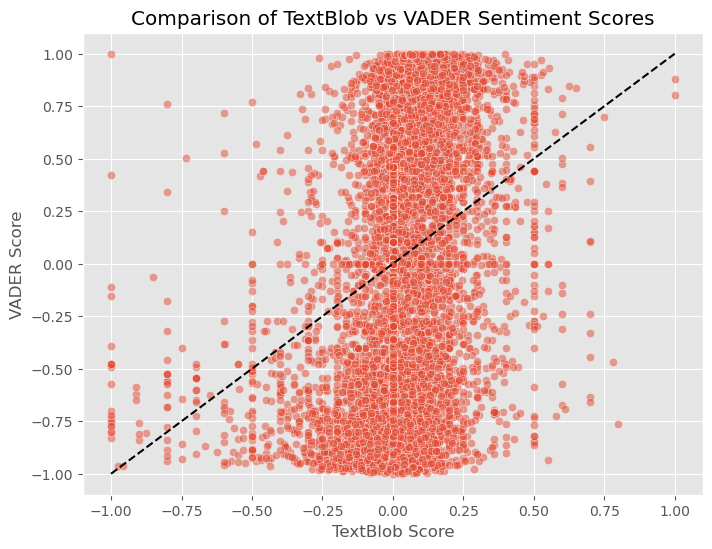

In [132]:
plt.style.use('ggplot')
plt.figure(figsize=(8,6))
sns.scatterplot(data=formatted_submissions_df, x='textblob_score', y='vader_score', alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='black', linestyle='--')
plt.title('Comparison of TextBlob vs VADER Sentiment Scores')
plt.xlabel('TextBlob Score')
plt.ylabel('VADER Score')
plt.grid(True)
plt.show()


In [133]:
formatted_submissions_df['score_difference'] = formatted_submissions_df['vader_score'] - formatted_submissions_df['textblob_score']

formatted_submissions_df['score_difference_abs'] = (formatted_submissions_df['vader_score'] - formatted_submissions_df['textblob_score']).abs()

formatted_submissions_df.sort_values('score_difference', ascending=True).head(10)

,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai
4277,AI-RFI-2025-8185.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",There’s nothing intelligent about genAI. It’s ...,-0.7636,0.800000,-1.563600,1.563600,,0.0000,0.00
6584,AI-RFI-2025-8211.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",This is going to kill art as we know it. We wi...,-0.9354,0.550000,-1.485400,1.485400,,0.0000,0.00
6716,AI-RFI-2025-1786.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","AI steals jobs from Americans, it will continu...",-0.8625,0.500000,-1.362500,1.362500,"AI steals jobs from Americans, it will continu...",-0.8625,0.50
4125,AI-RFI-2025-2906.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI cannot be granted free access to copyrighte...,-0.6608,0.700000,-1.360800,1.360800,AI cannot be granted free access to copyrighte...,0.1921,0.45
3726,AI-RFI-2025-2644.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Get rid of copyright then if you think this co...,-0.8504,0.500000,-1.350400,1.350400,,0.0000,0.00
3625,AI-RFI-2025-4802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.500000,-1.346500,1.346500,DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.50
683,AI-RFI-2025-4531.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.700000,-1.332400,1.332400,Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.70
7381,AI-RFI-2025-5332.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI is activily stealing from Americans with no...,-0.8225,0.500000,-1.322500,1.322500,AI is activily stealing from Americans with no...,-0.7096,0.00
7771,AI-RFI-2025-3678.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",You have no idea the damage this will do to ar...,-0.8225,0.500000,-1.322500,1.322500,,0.0000,0.00
7779,AI-RFI-2025-6072.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I am a writer and AI has demolished my livelih...,-0.7258,0.579167,-1.304967,1.304967,I am a writer and AI has demolished my livelih...,-0.7675,0.40


In [134]:
formatted_submissions_df.sort_values('score_difference', ascending=False).head(10)

,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai
2316,AI-RFI-2025-3649.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000,1.999600,1.999600,NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000
9810,AI-RFI-2025-5796.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Do NOT do this. Don't be stupid. Kill this ide...,0.7589,-0.800000,1.558900,1.558900,,0.0000,0.000000
4550,AI-RFI-2025-6948.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",This sounds an awful lot like saying one could...,0.4215,-1.000000,1.421500,1.421500,This sounds an awful lot like saying one could...,0.4215,-1.000000
6658,AI-RFI-2025-7320.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Copyrighted material should be protected from ...,0.7184,-0.600000,1.318400,1.318400,Copyrighted material should be protected from ...,0.7184,-0.600000
2584,AI-RFI-2025-5897.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Please don't fail to legislate AI like you did...,0.7684,-0.500000,1.268400,1.268400,Please don't fail to legislate AI like you did...,0.7684,-0.500000
7905,AI-RFI-2025-6259.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",If the government is going to forgo enforcing ...,0.9794,-0.260714,1.240114,1.240114,If the government is going to forgo enforcing ...,0.9794,-0.260714
105,AI-RFI-2025-8644.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",HANDS OF MY ART CLANKER SCUM!!!!\nAttachments\...,0.5053,-0.732422,1.237722,1.237722,,0.0000,0.000000
1381,AI-RFI-2025-6121.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial intelligence should be carefully re...,0.9400,-0.218182,1.158182,1.158182,Artificial intelligence should be carefully re...,0.8256,-0.326667
8189,AI-RFI-2025-5801.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial Intelligence needs to be regulated ...,0.9493,-0.200000,1.149300,1.149300,Artificial Intelligence needs to be regulated ...,0.9493,-0.200000
6642,AI-RFI-2025-1584.pdf,1,"As of: March 21, 2025\nReceived: March 14, 202...",While I understand the use of AI in pattern re...,0.3400,-0.800000,1.140000,1.140000,While I understand the use of AI in pattern re...,0.3612,0.000000


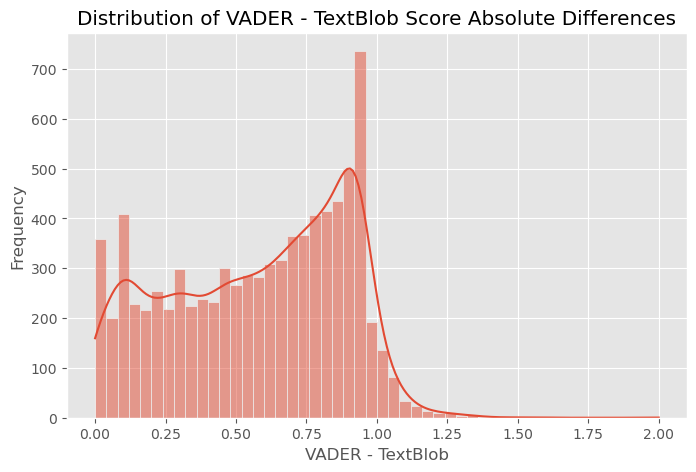

In [135]:
plt.style.use('ggplot')
plt.figure(figsize=(8,5))
sns.histplot(formatted_submissions_df['score_difference_abs'], bins=50, kde=True)
plt.title('Distribution of VADER - TextBlob Score Absolute Differences')
plt.xlabel('VADER - TextBlob')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


### Sentiment analysis of only sentences that contain AI or Artificial Intelligence

In [136]:
def extract_ai_sentences(text):
    if pd.isnull(text):
        return ''
    sentences = re.split(r'(?<=[.!?])\s+', text)

    # Filter for 'AI' or 'artificial intelligence' (case-insensitive)
    ai_sentences = [s for s in sentences if re.search(r'\b(AI|artificial intelligence)\b', s, re.IGNORECASE)]
    return ' '.join(ai_sentences)

# Create the new column
formatted_submissions_df['ai_mentions'] = formatted_submissions_df['comment_only'].apply(extract_ai_sentences)


In [137]:
analyzer = SentimentIntensityAnalyzer()

def vader_score(comment):
    scores = analyzer.polarity_scores(comment)
    return scores['compound']

formatted_submissions_df['vader_score_ai'] = formatted_submissions_df['ai_mentions'].progress_apply(vader_score)

100%|██████████| 8375/8375 [00:22<00:00, 374.51it/s]


In [138]:
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity

formatted_submissions_df['textblob_score_ai'] = formatted_submissions_df['ai_mentions'].progress_apply(get_textblob_sentiment)

100%|██████████| 8375/8375 [00:02<00:00, 3957.77it/s]


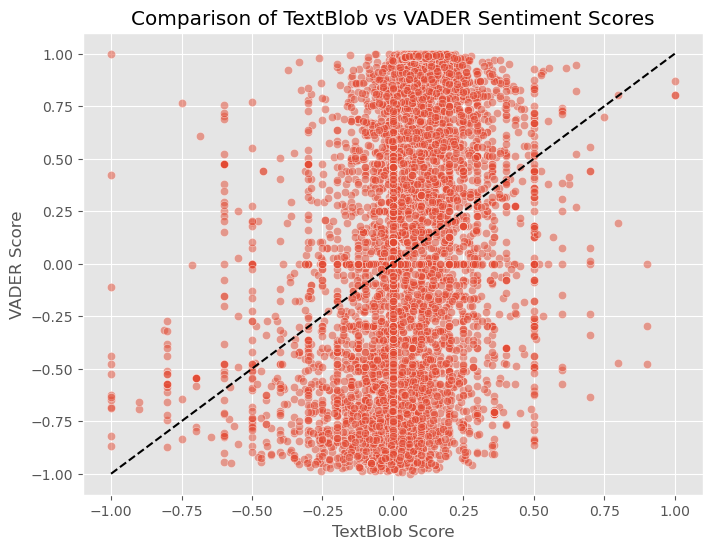

In [115]:
plt.style.use('ggplot')
plt.figure(figsize=(8,6))
sns.scatterplot(data=formatted_submissions_df, x='textblob_score_ai', y='vader_score_ai', alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='black', linestyle='--')
plt.title('Comparison of TextBlob vs VADER Sentiment Scores for AI mentions')
plt.xlabel('TextBlob Score')
plt.ylabel('VADER Score')
plt.grid(True)
plt.show()

In [141]:
formatted_submissions_df['score_difference_ai'] = formatted_submissions_df['vader_score_ai'] - formatted_submissions_df['textblob_score_ai']

formatted_submissions_df['score_difference_abs_ai'] = (formatted_submissions_df['vader_score_ai'] - formatted_submissions_df['textblob_score_ai']).abs()

formatted_submissions_df.sort_values('score_difference_ai', ascending=True).head(10)

,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai,score_difference_ai,score_difference_abs_ai
7006,AI-RFI-2025-6174.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","As an artist, I find AI incredibly dishearteni...",0.0009,0.260000,-0.259100,0.259100,"As an artist, I find AI incredibly disheartening.",-0.4754,0.900000,-1.375400,1.375400
6716,AI-RFI-2025-1786.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...","AI steals jobs from Americans, it will continu...",-0.8625,0.500000,-1.362500,1.362500,"AI steals jobs from Americans, it will continu...",-0.8625,0.500000,-1.362500,1.362500
3625,AI-RFI-2025-4802.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.500000,-1.346500,1.346500,DO NOT ALLOW OPEN AI TO SCOUR THE INTERNET TO ...,-0.8465,0.500000,-1.346500,1.346500
6236,AI-RFI-2025-6359.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Please no. We do not need AI taking over every...,-0.7696,0.500000,-1.269600,1.269600,We do not need AI taking over everything becau...,-0.8388,0.500000,-1.338800,1.338800
2885,AI-RFI-2025-2096.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI has wrought havoc in all creative fields an...,-0.8658,0.150000,-1.015800,1.015800,AI has wrought havoc in all creative fields an...,-0.8360,0.500000,-1.336000,1.336000
683,AI-RFI-2025-4531.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.700000,-1.332400,1.332400,Ai sould not be fair use. Ai is stolen data fr...,-0.6324,0.700000,-1.332400,1.332400
7200,AI-RFI-2025-3352.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Generative AI is nothing more than an overpric...,0.4678,0.161250,0.306550,0.306550,Generative AI is nothing more than an overpric...,-0.7906,0.500000,-1.290600,1.290600
6737,AI-RFI-2025-3813.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",All OpenAI does is steal other peoples' creati...,-0.5223,0.391667,-0.913967,0.913967,"AI should be doing our taxes, not sucking the ...",-0.4717,0.800000,-1.271700,1.271700
7855,AI-RFI-2025-6516.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",I believe that AI is overhyped and already sho...,-0.7650,0.250000,-1.015000,1.015000,I believe that AI is overhyped and already sho...,-0.7650,0.500000,-1.265000,1.265000
8919,AI-RFI-2025-9233.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",AI companies should be held to the rules of th...,-0.9073,0.357143,-1.264443,1.264443,AI companies should be held to the rules of th...,-0.9073,0.357143,-1.264443,1.264443


In [142]:
formatted_submissions_df.sort_values('score_difference_ai', ascending=False).head(10)

,filename,page_count,text,comment_only,vader_score,textblob_score,score_difference,score_difference_abs,ai_mentions,vader_score_ai,textblob_score_ai,score_difference_ai,score_difference_abs_ai
2316,AI-RFI-2025-3649.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000,1.999600,1.999600,NO NO NO NO NO NO NO NO NO NO NO NO NO NO NO N...,0.9996,-1.000000,1.999600,1.999600
1592,AI-RFI-2025-5776.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Any and all AI LLMs and artificial intelligenc...,0.4199,-0.472222,0.892122,0.892122,Any and all AI LLMs and artificial intelligenc...,0.7644,-0.750000,1.514400,1.514400
4550,AI-RFI-2025-6948.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",This sounds an awful lot like saying one could...,0.4215,-1.000000,1.421500,1.421500,This sounds an awful lot like saying one could...,0.4215,-1.000000,1.421500,1.421500
1813,AI-RFI-2025-6861.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial Intelligence and anything like it s...,0.8225,-0.100000,0.922500,0.922500,Artificial Intelligence and anything like it s...,0.7579,-0.600000,1.357900,1.357900
6658,AI-RFI-2025-7320.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Copyrighted material should be protected from ...,0.7184,-0.600000,1.318400,1.318400,Copyrighted material should be protected from ...,0.7184,-0.600000,1.318400,1.318400
4650,AI-RFI-2025-8568.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial intelligence will do nothing but ha...,0.0964,-0.200000,0.296400,0.296400,Artificial intelligence will do nothing but ha...,0.7027,-0.600000,1.302700,1.302700
4384,AI-RFI-2025-5851.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Please do not allow the destruction of copyrig...,0.9651,-0.039782,1.004882,1.004882,Please do not allow the destruction of copyrig...,0.9221,-0.372917,1.295017,1.295017
515,AI-RFI-2025-1107.pdf,1,"As of: March 21, 2025\nReceived: March 07, 202...",My greatest concern about artificial intellige...,0.9633,-0.064855,1.028155,1.028155,My greatest concern about artificial intellige...,0.9603,-0.333333,1.293633,1.293633
6421,AI-RFI-2025-5324.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",Artificial Intelligence (AI) isn’t a foolproof...,0.7717,-0.108333,0.880033,0.880033,Artificial Intelligence (AI) isn’t a foolproof...,0.6908,-0.600000,1.290800,1.290800
1263,AI-RFI-2025-2186.pdf,1,"As of: March 21, 2025\nReceived: March 15, 202...",The people's voice must be heard. AI isn't jus...,0.8820,-0.117256,0.999256,0.999256,"AI isn't just bad for artists, its use require...",0.6059,-0.683333,1.289233,1.289233


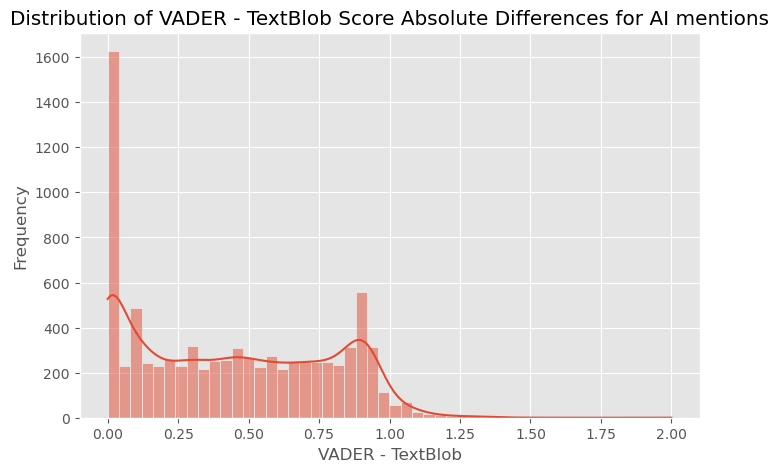

In [144]:
plt.style.use('ggplot')
plt.figure(figsize=(8,5))
sns.histplot(formatted_submissions_df['score_difference_abs_ai'], bins=50, kde=True)
plt.title('Distribution of VADER - TextBlob Score Absolute Differences for AI mentions')
plt.xlabel('VADER - TextBlob')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## # - Scrape info from NITRD Table
- clean file name and respondent type from [link](https://www.nitrd.gov/coordination-areas/ai/90-fr-9088-responses/)

In [16]:
# Step 1: Scrape the page
url = "https://www.nitrd.gov/coordination-areas/ai/90-fr-9088-responses/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# Step 2: Find the table rows
table_rows = soup.select("table tbody tr")

data = []

for row in table_rows:
    cells = row.find_all("td")
    if len(cells) >= 3:
        display_name = cells[0].get_text(strip=True)
        respondent_type = cells[1].get_text(strip=True)
        link_tag = cells[2].find("a")

        if link_tag and "href" in link_tag.attrs:
            pdf_url = link_tag["href"]
            # Extract filename from URL
            pdf_filename = urlparse(pdf_url).path.split("/")[-1]
            data.append({
                "filename": pdf_filename,
                "respondent_name": display_name,
                "respondent_type": respondent_type
            })

# Step 3: Create a DataFrame from the scraped data
respondent_df = pd.DataFrame(data)

# # Step 4: Merge with your existing PDF DataFrame
# pdf_df = pdf_df.merge(respondent_df, on="filename", how="left")

# # Now pdf_df contains columns: filename, page_count, respondent_name, respondent_type

In [18]:
table_rows

[]

In [ ]:

# Step 1: Scrape the page
url = "https://www.nitrd.gov/coordination-areas/ai/90-fr-9088-responses/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

# Step 2: Find the table rows
table_rows = soup.select("table tbody tr")

data = []

for row in table_rows:
    cells = row.find_all("td")
    if len(cells) >= 3:
        display_name = cells[0].get_text(strip=True)
        respondent_type = cells[1].get_text(strip=True)
        link_tag = cells[2].find("a")

        if link_tag and "href" in link_tag.attrs:
            pdf_url = link_tag["href"]
            # Extract filename from URL
            pdf_filename = urlparse(pdf_url).path.split("/")[-1]
            data.append({
                "filename": pdf_filename,
                "respondent_name": display_name,
                "respondent_type": respondent_type
            })

# Step 3: Create a DataFrame from the scraped data
respondent_df = pd.DataFrame(data)

# Step 4: Merge with your existing PDF DataFrame
pdf_df = pdf_df.merge(respondent_df, on="filename", how="left")

# Now pdf_df contains columns: filename, page_count, respondent_name, respondent_type
